In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle
from tensorflow.keras.models import load_model


In [2]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,f1_score,r2_score,roc_auc_score

In [3]:
model=load_model("../models/lstm_autoencoder_final.keras")

In [4]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 30, 64)            34048     
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 repeat_vector (RepeatVecto  (None, 30, 32)            0         
 r)                                                              
                                                                 
 lstm_2 (LSTM)               (None, 30, 32)            8320      
                                                                 
 lstm_3 (LSTM)               (None, 30, 64)            24832     
                                                                 
 time_distributed (TimeDist  (None, 30, 68)            4420      
 ributed)                                               

In [5]:
scaler=joblib.load("../models/scaler.pkl")

In [6]:
x_train_seq=np.load("../processed/X_train_sequence.npy")

In [7]:
x_test_seq=np.load("../processed/X_test_sequence.npy")

In [8]:
y_test=np.load("../processed/y_test.npy")

In [9]:
unique, counts = np.unique(
    y_test,
    return_counts=True
)


for label,count in zip(unique,counts):
    print(label,count)

BENIGN 95039
DDoS 128014


In [10]:
x_train_pred=model.predict(
    x_train_seq,
    batch_size=256
)

372/372 [==============================] - 52s 128ms/step


In [11]:
train_error=np.mean(
    np.square(x_train_seq-x_train_pred),axis=(1,2)
)
train_error.shape

(95039,)

In [12]:
threshold=(
    np.percentile(train_error,95)
)
print("threshold for anomly detection =",threshold)

threshold for anomly detection = 2.2573096513748165


In [13]:
x_test_pred=model.predict(
    x_test_seq,
    batch_size=256
)

872/872 [==============================] - 71s 81ms/step


In [14]:
print(x_train_seq.shape)
print(x_test_seq.shape)
print(x_test_pred.shape)
print(model.input_shape)

(95039, 30, 68)
(223053, 30, 68)
(223053, 30, 68)
(None, 30, 68)


In [15]:
test_error = []

batch_size = 1024

for start in range(0, len(x_test_seq), batch_size):

    end = min(start + batch_size, len(x_test_seq))

    batch_true = x_test_seq[start:end]
    batch_pred = x_test_pred[start:end]

    batch_error = np.mean(
        np.square(batch_true - batch_pred),
        axis=(1, 2)
    )

    test_error.extend(batch_error)

test_error = np.array(test_error)

print("Test Error Shape:", test_error.shape)

Test Error Shape: (223053,)


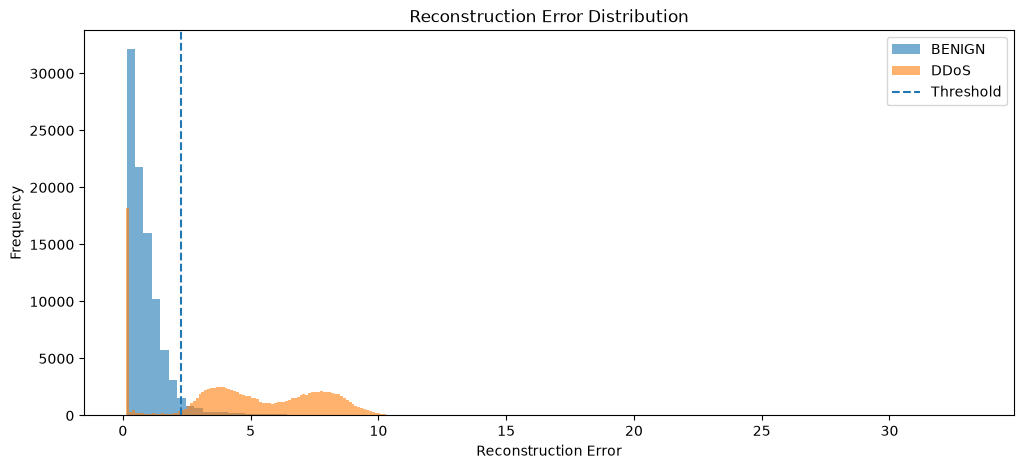

In [16]:
plt.figure(figsize=(12,5))


plt.hist(
    test_error[y_test=="BENIGN"],
    bins=100,
    alpha=0.6,
    label="BENIGN"
)


plt.hist(
    test_error[y_test=="DDoS"],
    bins=100,
    alpha=0.6,
    label="DDoS"
)


plt.axvline(
    threshold,
    linestyle="--",
    label="Threshold"
)


plt.xlabel(
    "Reconstruction Error"
)


plt.ylabel(
    "Frequency"
)


plt.title(
    "Reconstruction Error Distribution"
)


plt.legend()

plt.show()

In [17]:
threshold = np.percentile(train_error, 95)

print(f"Selected Threshold : {threshold:.6f}")

Selected Threshold : 2.257310


In [18]:
y_pred = np.where(
    test_error > threshold,
    "DDoS",
    "BENIGN"
)

In [19]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

      BENIGN       0.80      0.95      0.87     95039
        DDoS       0.95      0.83      0.89    128014

    accuracy                           0.88    223053
   macro avg       0.88      0.89      0.88    223053
weighted avg       0.89      0.88      0.88    223053



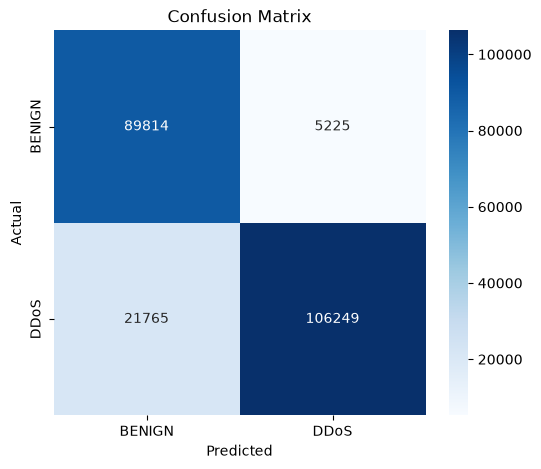

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["BENIGN", "DDoS"]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN","DDoS"],
    yticklabels=["BENIGN","DDoS"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [21]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    pos_label="DDoS"
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label="DDoS"
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label="DDoS"
)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.8790
Precision : 0.9531
Recall    : 0.8300
F1 Score  : 0.8873


In [22]:
import pickle
with open("../models/threshold.pkl", "wb") as file:
    pickle.dump(threshold, file)

print("Threshold saved successfully.")

Threshold saved successfully.
